In [1]:
!pip install yfinance pandas numpy matplotlib

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Setup complete! All packages imported successfully.")

Setup complete! All packages imported successfully.


In [9]:
%%writefile .gitignore
data/
.ipynb_checkpoints/

Overwriting .gitignore


In [4]:
#Defining my parameters
ticker = "SPY"
interval = "15m"
period = "60d" #Max is 60 for intraday

print(f"Downloading {interval} data for {ticker}...")

#Fetch the actual data
df = yf.download(ticker, period = period, interval = interval)

#We have multi-index problem lets fix it
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

#Cleaning data
df.dropna(inplace=True)
df.columns = [c.lower() for c in df.columns]

# Save directly to your local data folder
file_path = f"data/{ticker}_{interval}_data.csv"
df.to_csv(file_path)

print(f"Data saved to {file_path}. Total rows: {len(df)}")

[*********************100%***********************]  1 of 1 completed

Data saved to data/SPY_15m_data.csv. Total rows: 1560


In [16]:

#Smart file locator to bypass the folder glitch
if os.path.exists("data/data/SPY_15m_data.csv"):
    target_file = "data/data/SPY_15m_data.csv"
else:
    target_file = "data/SPY_15m_data.csv"

#Load the data back from your CSV
data = pd.read_csv(target_file, index_col=0, parse_dates=True)

#Calculate Market Returns (candle to candle)
data['market_return'] = data['close'].pct_change()

#Baseline 1: Buy & Hold
data['buy_and_hold'] = (1 + data['market_return']).cumprod()

#Baseline 2: Random Trader
np.random.seed(42) # Keeps the random results identical every time you run it
data['random_signal'] = np.random.choice([1, -1, 0], size=len(data))
data['random_return'] = data['random_signal'].shift(1) * data['market_return']
data['random_cumulative'] = (1 + data['random_return']).cumprod()

#Print the final results
print("--- STRATEGY BASELINES (Last 60 Days) ---")
print(f"Buy & Hold Return: {(data['buy_and_hold'].iloc[-1] - 1) * 100:.2f}%")
print(f"Random Trader Return: {(data['random_cumulative'].iloc[-1] - 1) * 100:.2f}%")

--- STRATEGY BASELINES (Last 60 Days) ---
Buy & Hold Return: 5.40%
Random Trader Return: -4.86%


Running 1000 Monte Carlo simulations. Please wait...


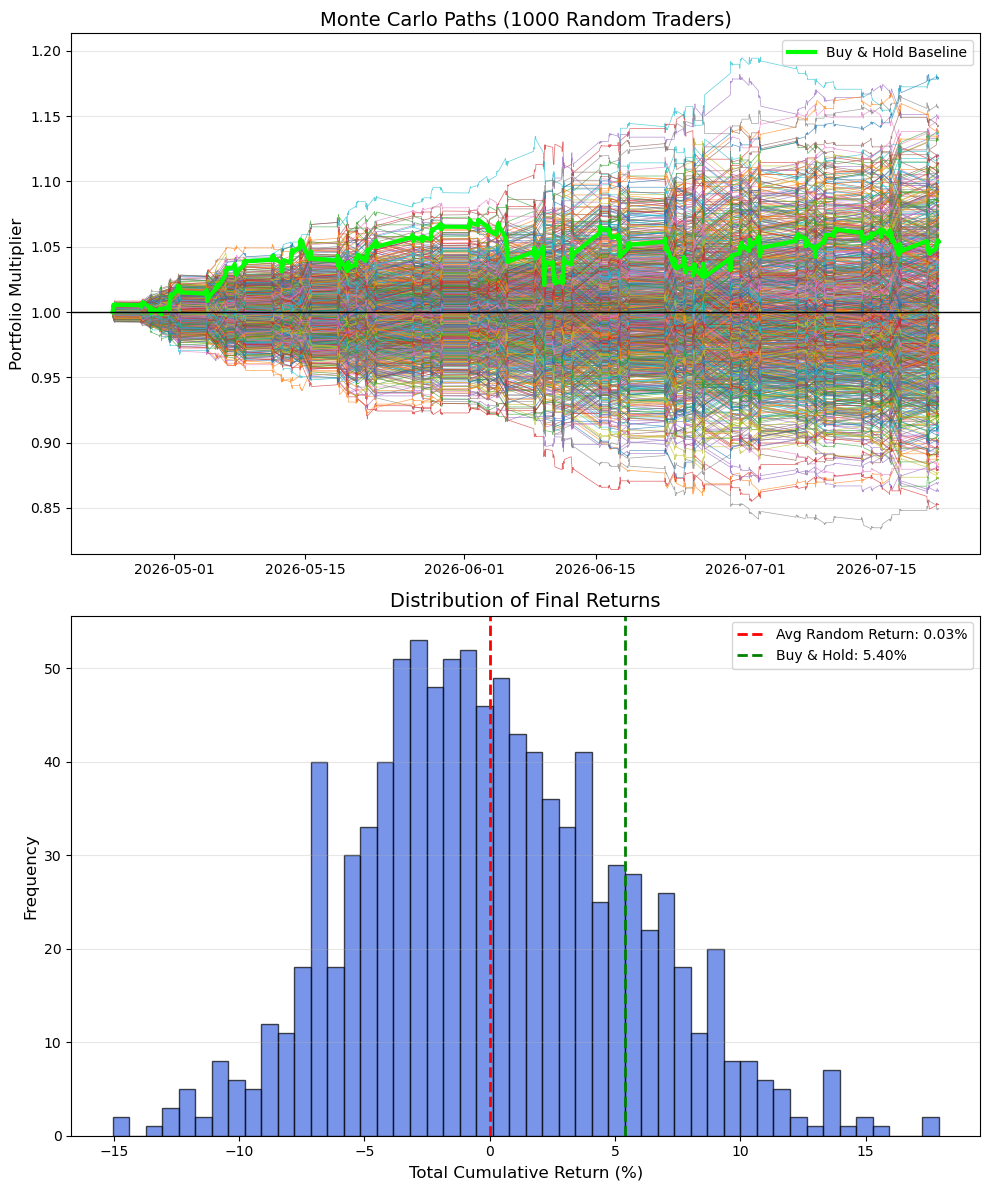

--- MONTE CARLO RESULTS ---
True Average Random Return: 0.03%
Buy & Hold Return: 5.40%


In [25]:

#Setup the simulation parameters
n_simulations = 1000
final_returns = []
all_equity_curves = []

print(f"Running {n_simulations} Monte Carlo simulations. Please wait...")

#Run the loop ONCE, but save BOTH sets of data
for i in range(n_simulations):
    random_signal = np.random.choice([1, -1, 0], size=len(data))

    random_return = pd.Series(random_signal, index=data.index).shift(1) * data['market_return']
    cumulative_return = (1 + random_return).cumprod()
    
    all_equity_curves.append(cumulative_return)
    
    final_returns.append((cumulative_return.iloc[-1] - 1) * 100)

#Calculate benchmarks
avg_mc_return = np.mean(final_returns)
buy_and_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

#Generate the Visualization (2 Rows, 1 Column)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# --- CHART 1: The Spaghetti Chart (Top) ---
for curve in all_equity_curves:
    axes[0].plot(curve.index, curve, alpha=0.7, linewidth=0.5)

axes[0].plot(data.index, data['buy_and_hold'], color='lime', linewidth=3, label='Buy & Hold Baseline')
axes[0].axhline(1.0, color='black', linestyle='solid', linewidth=1)
axes[0].set_title(f'Monte Carlo Paths ({n_simulations} Random Traders)', fontsize=14)
axes[0].set_ylabel('Portfolio Multiplier', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- CHART 2: The Histogram (Bottom) ---
axes[1].hist(final_returns, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
axes[1].axvline(avg_mc_return, color='red', linestyle='dashed', linewidth=2, 
            label=f'Avg Random Return: {avg_mc_return:.2f}%')
axes[1].axvline(buy_and_hold_return, color='green', linestyle='dashed', linewidth=2, 
            label=f'Buy & Hold: {buy_and_hold_return:.2f}%')

axes[1].set_title('Distribution of Final Returns', fontsize=14)
axes[1].set_xlabel('Total Cumulative Return (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

#Display the charts neatly
plt.tight_layout()
plt.show()

#Output the final stats
print("--- MONTE CARLO RESULTS ---")
print(f"True Average Random Return: {avg_mc_return:.2f}%")
print(f"Buy & Hold Return: {buy_and_hold_return:.2f}%")